# MVTec-AD Industrial Anomaly Detection
This notebook trains a lightweight convolutional autoencoder for **image-level industrial anomaly detection** and **pixel-level defect localization** on the MVTec Anomaly Detection (MVTec AD) dataset.

For the dataset:
> https://www.kaggle.com/datasets/ipythonx/mvtec-ad/data

### Training design

- **Dataset:** MVTec AD downloaded from Kaggle
- **Framework:** PyTorch
- **Model:** Lightweight Convolutional Autoencoder
- **Training data:** Normal (`good`) images only
- **Input:** RGB, resized to 128 × 128
- **Anomaly score:** Mean Squared Error (MSE) between input and reconstruction
- **Image-level threshold:** selected from a held-out normal validation set using a high percentile
- **Pixel-level localization:** reconstruction-error map + threshold
- **Evaluation:** image-level ROC-AUC / PR-AUC / precision / recall / F1, plus pixel-level ROC-AUC / IoU / Dice when masks are available
- **Export:** PyTorch checkpoint containing the model state and inference configuration

> The model is intentionally kept lightweight so that it can be trained within the Google Colab Free Tier. The implementation is also straightforward to reproduce and integrate into the FastAPI web application later.

### Why PyTorch?

PyTorch is used because it provides a simple and transparent training loop, convenient tensor operations for reconstruction-based anomaly detection, and straightforward model export/loading. The same pipeline can be implemented with Keras/TensorFlow, but PyTorch is selected here to keep the training and inference logic explicit and easy to adapt.

> **Important:** MVTec AD is organized by product/texture category. A reconstruction model is trained **per category**, because what is considered normal for `bottle` is different from `cable`, `hazelnut`, `tile`, etc. Change `CATEGORY` below to train another category.


# Configuration

The default category is `bottle`. Change `CATEGORY` when you want to train a separate model for another MVTec AD Category.

For the first Colab run, keep the default settings. The model uses relatively small images and a compact architecture to reduce memory and training time.

In [1]:
# Configuration
CATEGORY="bottle" # Examle: bottle, cable, capsule, hazelnut, tile, etc (see dataset)
IMAGE_SIZE=128
BATCH_SIZE=32
EPOCHS=30
LEARNING_RATE=1e-3
WEIGHT_DECAY=1e-5
VAL_RATIO=0.20
RANDOM_SEED=42

'''
Threshold strategy:
"percentile" is the recommended default for an supervised setting.
The threshold is calculated only from normal validation images.
'''
THRESHOLD_PERCENTILE=99.0

'''
Pixel localization threshold is calculated from normal validation
reconstruction-error pixels.
'''
PIXEL_THRESHOLD_PERCENTILE=99.5

# Early stopping
PATIENCE=7

# Output Directory
OUTPUT_DIR="/content/mvtec_outputs"

print("Category:", CATEGORY)
print("Image size", IMAGE_SIZE)
print("Batch size", BATCH_SIZE)
print("Epochs", EPOCHS)
print("Learning rate", LEARNING_RATE)
print("Weight decay", WEIGHT_DECAY)
print("Validation ratio", VAL_RATIO)
print("Random seed", RANDOM_SEED)
print("Threshold strategy", "percentile")
print("Pixel threshold strategy", "percentile")
print("Early stopping patience", PATIENCE)
print("Output directory", OUTPUT_DIR)

Category: bottle
Image size 128
Batch size 32
Epochs 30
Learning rate 0.001
Weight decay 1e-05
Validation ratio 0.2
Random seed 42
Threshold strategy percentile
Pixel threshold strategy percentile
Early stopping patience 7
Output directory /content/mvtec_outputs


Install/Import dependencies

In [2]:
!pip -q install kaggle scikit-learn opencv-python-headless

In [5]:
import os
import json
import random
import shutil
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve
)

SEED=RANDOM_SEED
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
  torch.cuda.manual_seed_all(SEED)

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device: ", device)
if torch.cuda.is_available():
  print("GPU:", torch.cuda.get_device_name(0))

os.makedirs(OUTPUT_DIR, exist_ok=True)



PyTorch: 2.11.0+cpu
Device:  cpu


# Download MVTec AD from Kaggle

The dataset is intentionally not committed to GitHub repository because of its size.

Upload your Kaggle API token (kaggle.json) when prompted. In Kaggle:
> **Account → Settings → API → Create New Token**

The dataset used by this project is:
`ipthonx/mvtec-ad`


In [15]:
from google.colab import files

KAGGLE_DIR=Path("/root/.kaggle")
KAGGLE_DIR.mkdir(parents=True, exist_ok=True)

if not(KAGGLE_DIR/"kaggle.json").exists():
  print("Upload your kaggle.json file.")
  uploaded=files.upload()

  if "kaggle.json" not in uploaded:
        raise FileNotFoundError("kaggle.json was not uploaded.")

DATASET_DIR=Path("/content/mvtec_dataset")
DATASET_DIR.mkdir(parents=True, exist_ok=True)

zip_path=Path("content/mvtec-ad.zip")
if not zip_path.exists():
  !kaggle datasets download -d ipythonx/mvtec-ad -p /content
  # !unzip -q /content/mvtec-ad.zip -d /content/mvtec_dataset

downloaded = list(Path("/content").glob("mvtec-ad*.zip"))
if downloaded:
    zip_path = downloaded[0]

if not any(DATASET_DIR.iterdir()):
    print("Extracting:", zip_path)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(DATASET_DIR)

print("Dataset extracted to:", DATASET_DIR)

Upload your kaggle.json file.


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/ipythonx/mvtec-ad
License(s): copyright-authors
mvtec-ad.zip: Skipping, found more recently modified local copy (use --force to force download)
Extracting: /content/mvtec-ad.zip
Dataset extracted to: /content/mvtec_dataset


In [16]:
def find_category_dir(root: Path, category: str) -> Path:
    candidates = []

    for p in root.rglob(category):
        if p.is_dir():
            train_good = p / "train" / "good"
            test_dir = p / "test"
            gt_dir = p / "ground_truth"
            if train_good.exists() and test_dir.exists():
                candidates.append(p)

    if not candidates:
        raise FileNotFoundError(
            f"Could not find category '{category}' under {root}. "
            "Check the extracted dataset structure."
        )

    # Prefer the shallowest valid directory.
    candidates.sort(key=lambda p: len(p.parts))
    return candidates[0]

CATEGORY_DIR = find_category_dir(DATASET_DIR, CATEGORY)

TRAIN_GOOD_DIR = CATEGORY_DIR / "train" / "good"
TEST_DIR = CATEGORY_DIR / "test"
GROUND_TRUTH_DIR = CATEGORY_DIR / "ground_truth"

print("Category directory:", CATEGORY_DIR)
print("Train good:", TRAIN_GOOD_DIR)
print("Test:", TEST_DIR)
print("Ground truth:", GROUND_TRUTH_DIR)
print("Test defect types:", [p.name for p in TEST_DIR.iterdir() if p.is_dir()])


Category directory: /content/mvtec_dataset/bottle
Train good: /content/mvtec_dataset/bottle/train/good
Test: /content/mvtec_dataset/bottle/test
Ground truth: /content/mvtec_dataset/bottle/ground_truth
Test defect types: ['broken_small', 'broken_large', 'contamination', 'good']


# Dataset inspection


The model is trained only on train/good

The official MVTec AD test split contains normal and defective samples. For model selection, the normal training data is split into:
- training subset
- normal validation subset

This avoid using the final test set to select the image-level threshold.


In [17]:
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

def list_images(directory: Path):
    return sorted([
        p for p in directory.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ])

all_good = list_images(TRAIN_GOOD_DIR)

if len(all_good) < 10:
    raise RuntimeError(f"Too few training images found: {len(all_good)}")

rng = random.Random(RANDOM_SEED)
rng.shuffle(all_good)

val_count = max(1, int(len(all_good) * VAL_RATIO))
val_paths = all_good[:val_count]
train_paths = all_good[val_count:]

print(f"Total normal training images : {len(all_good)}")
print(f"Training images              : {len(train_paths)}")
print(f"Validation images            : {len(val_paths)}")


Total normal training images : 209
Training images              : 168
Validation images            : 41


Test Set Collection

In [18]:
test_records = []

for defect_dir in sorted([p for p in TEST_DIR.iterdir() if p.is_dir()]):
    defect_type = defect_dir.name
    label = 0 if defect_type == "good" else 1

    for img_path in list_images(defect_dir):
        test_records.append({
            "path": str(img_path),
            "defect_type": defect_type,
            "label": label
        })

test_df = pd.DataFrame(test_records)

print(test_df["defect_type"].value_counts())
print()
print("Test images:", len(test_df))
print("Normal:", int((test_df["label"] == 0).sum()))
print("Anomaly:", int((test_df["label"] == 1).sum()))


defect_type
broken_small     22
contamination    21
broken_large     20
good             20
Name: count, dtype: int64

Test images: 83
Normal: 20
Anomaly: 63


# PyTorch dataset and preprocessing

The input is resize to `128 × 128` and scaled to `[0 to 1]`.

No aggresive augmentations is used because of the objective is to reconstruct the normal appearance of a specific industrial category. Excessive augmentation could alter the visual characteristics that the model is expected to learn.

In [19]:
class MVTecImageDataset(Dataset):
    def __init__(self, paths, image_size=128):
        self.paths = [str(p) for p in paths]
        self.image_size = image_size

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]

        image = cv2.imread(path, cv2.IMREAD_COLOR)
        if image is None:
            raise ValueError(f"Failed to read image: {path}")

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(
            image,
            (self.image_size, self.image_size),
            interpolation=cv2.INTER_AREA
        )

        image = image.astype(np.float32) / 255.0
        image = np.transpose(image, (2, 0, 1))
        tensor = torch.from_numpy(image)

        return tensor, path


train_dataset = MVTecImageDataset(train_paths, IMAGE_SIZE)
val_dataset = MVTecImageDataset(val_paths, IMAGE_SIZE)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))


Train batches: 6
Val batches: 2


Visualize samples

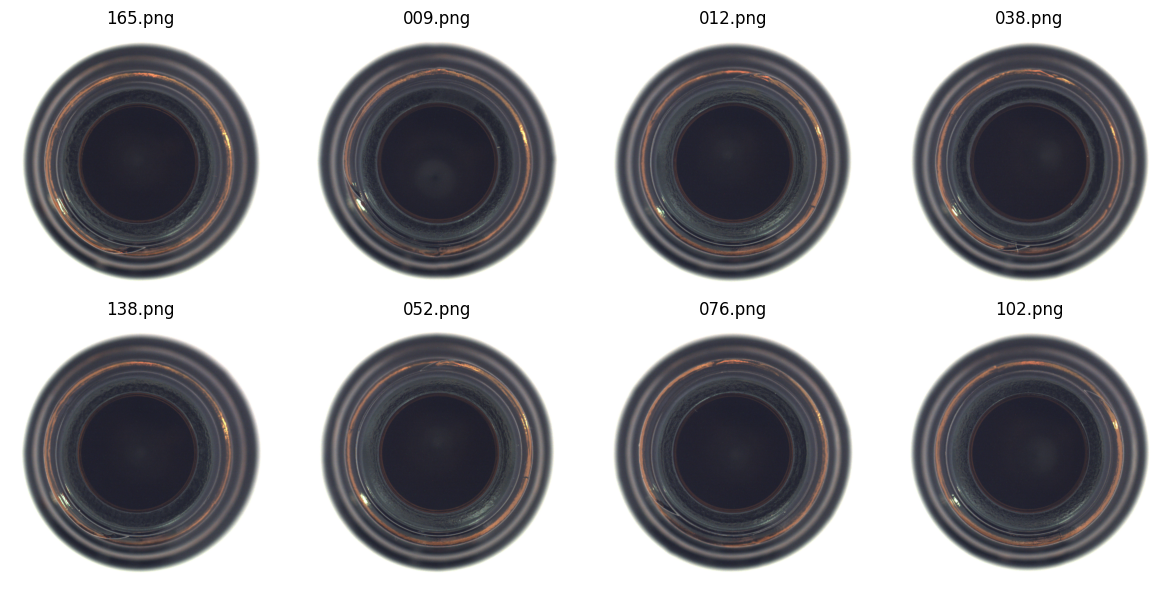

In [20]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax, path in zip(axes.ravel(), train_paths[:8]):
    image = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)
    ax.imshow(image)
    ax.set_title(Path(path).name)
    ax.axis("off")

plt.tight_layout()
plt.show()


# Lightweight Convolutional Autoencoder

The model uses a compact encoder-decoder architecture:

```text
128x128x3
   |
Conv 32
   |
Conv 64
   |
Conv 128
   |
Latent feature map
   |
ConvTranspose 64
   |
ConvTranspose 32
   |
ConvTranspose 3
   |
128x128x3 reconstruction
```

This is deliberately much smaller than large industrial anomaly-detection backbones such as WideResNet-based PatchCore pipelines.

The anomaly score is the mean pixel-wise squared reconstruction error.


In [21]:
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 128, kernel_size=3, stride=2, padding=1),
            nn.ReLU(inplace=True),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(
                128, 128, kernel_size=4, stride=2, padding=1
            ),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(
                128, 64, kernel_size=4, stride=2, padding=1
            ),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(
                64, 32, kernel_size=4, stride=2, padding=1
            ),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(
                32, 3, kernel_size=4, stride=2, padding=1
            ),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        reconstruction = self.decoder(z)
        return reconstruction


model = ConvAutoencoder().to(device)

parameter_count = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"Trainable parameters: {parameter_count:,}")


ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU(inplace=True)
    (6): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(32, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): Sigmoid()
  )
)
Trainable parameters: 668,579


Loss, optimizer and helper functions

In [22]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train(training)

    total_loss = 0.0
    total_samples = 0

    for images, _ in loader:
        images = images.to(device, non_blocking=True)

        if training:
            optimizer.zero_grad(set_to_none=True)

        recon = model(images)
        loss = criterion(recon, images)

        if training:
            loss.backward()
            optimizer.step()

        batch_size = images.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

    return total_loss / max(total_samples, 1)


# Model Training

Early stopping is included to reduce unnecessary training once validation reconstruction loss stops improving.

The best checkpoint is selected using **normal validation reconstruction loss**, not the final test set.

In [24]:
history = {
    "train_loss": [],
    "val_loss": []
}

best_val_loss = float("inf")
best_state = None
epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):
    train_loss = run_epoch(model, train_loader, optimizer)
    val_loss = run_epoch(model, val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping triggered.")
        break

if best_state is None:
    raise RuntimeError("No model checkpoint was saved.")

model.load_state_dict(best_state)
model.eval()

print(f"Best validation loss: {best_val_loss:.6f}")

Epoch 01/30 | Train Loss: 0.131525 | Val Loss: 0.130777
Epoch 02/30 | Train Loss: 0.123075 | Val Loss: 0.083046
Epoch 03/30 | Train Loss: 0.067320 | Val Loss: 0.053467
Epoch 04/30 | Train Loss: 0.045506 | Val Loss: 0.031172
Epoch 05/30 | Train Loss: 0.025554 | Val Loss: 0.019505
Epoch 06/30 | Train Loss: 0.015612 | Val Loss: 0.011896
Epoch 07/30 | Train Loss: 0.011230 | Val Loss: 0.009645
Epoch 08/30 | Train Loss: 0.008971 | Val Loss: 0.007912
Epoch 09/30 | Train Loss: 0.007393 | Val Loss: 0.006617
Epoch 10/30 | Train Loss: 0.006304 | Val Loss: 0.005573
Epoch 11/30 | Train Loss: 0.005348 | Val Loss: 0.004746
Epoch 12/30 | Train Loss: 0.004561 | Val Loss: 0.004638
Epoch 13/30 | Train Loss: 0.004573 | Val Loss: 0.003680
Epoch 14/30 | Train Loss: 0.003641 | Val Loss: 0.003328
Epoch 15/30 | Train Loss: 0.003295 | Val Loss: 0.003086
Epoch 16/30 | Train Loss: 0.003097 | Val Loss: 0.005842
Epoch 17/30 | Train Loss: 0.004961 | Val Loss: 0.003063
Epoch 18/30 | Train Loss: 0.003753 | Val Loss: 0

Plot training history

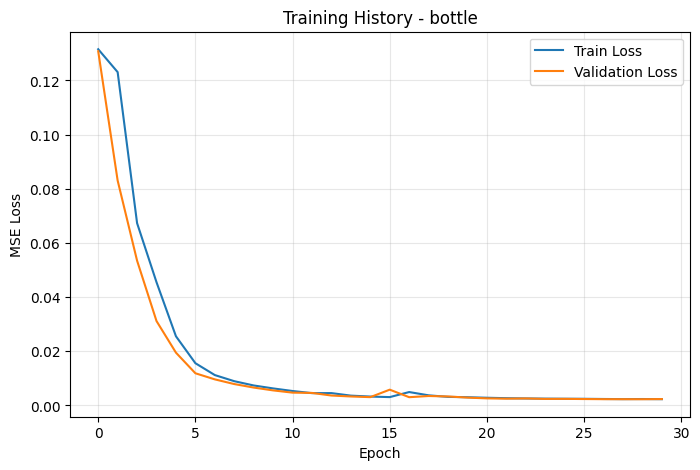

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title(f"Training History - {CATEGORY}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Reconstruction-error Functions

Two output are required for this project:
1. **Image-level anomaly score**: mean reconstruction error over the entire image.
2. **Pixel-level anomaly map**: reconstruction error at each pixel.

In [26]:
@torch.no_grad()
def reconstruct_batch(model, images):
    images = images.to(device, non_blocking=True)
    recon = model(images)
    return images, recon

@torch.no_grad()
def score_dataset(model, loader):
    model.eval()

    image_scores = []
    pixel_maps = []
    paths = []

    for images, batch_paths in loader:
        images, recon = reconstruct_batch(model, images)

        errors = (images - recon) ** 2
        batch_scores = errors.mean(dim=(1, 2, 3))
        batch_maps = errors.mean(dim=1)  # H x W

        image_scores.extend(batch_scores.cpu().numpy().tolist())
        pixel_maps.extend(batch_maps.cpu().numpy())
        paths.extend(batch_paths)

    return (
        np.asarray(image_scores, dtype=np.float32),
        np.asarray(pixel_maps, dtype=np.float32),
        paths
    )


# Normal validation scores for threshold selection
val_scores, val_maps, val_score_paths = score_dataset(model, val_loader)

print("Validation score statistics:")
print(pd.Series(val_scores).describe())

Validation score statistics:
count    41.000000
mean      0.002315
std       0.000291
min       0.001744
25%       0.002158
50%       0.002275
75%       0.002521
max       0.003098
dtype: float64


# Image-level threshold selection

For a one-class anomaly detection setup, the recommended default is a high percentile of **normal validation reconstruction errors**.

Here the threshold is:  
`99th percentile of normal validation image scores`

This is preferable to using the final test labels to select the threshold because the test set remains an evaluation set.

A Youden's J threshold can also be reported as an **analysis-only reference**, but it should not be used as the primary deployment threshold unless a separate labeled validation set is intentionally reseved for threshold calibration.



In [27]:
image_threshold = float(
    np.percentile(val_scores, THRESHOLD_PERCENTILE)
)

print(
    f"Image threshold ({THRESHOLD_PERCENTILE:.1f}th percentile): "
    f"{image_threshold:.8f}"
)

# Pixel threshold for localization
normal_pixels = val_maps.reshape(-1)
# Subsample to keep percentile computation memory-friendly
if len(normal_pixels) > 2_000_000:
    rng = np.random.default_rng(RANDOM_SEED)
    sample_idx = rng.choice(
        len(normal_pixels), size=2_000_000, replace=False
    )
    normal_pixels_for_threshold = normal_pixels[sample_idx]
else:
    normal_pixels_for_threshold = normal_pixels

pixel_threshold = float(
    np.percentile(
        normal_pixels_for_threshold,
        PIXEL_THRESHOLD_PERCENTILE
    )
)

print(
    f"Pixel threshold ({PIXEL_THRESHOLD_PERCENTILE:.1f}th percentile): "
    f"{pixel_threshold:.8f}"
)


Image threshold (99.0th percentile): 0.00302153
Pixel threshold (99.5th percentile): 0.03566422


Optional Youden's J threshold analysis

In [28]:
def compute_test_scores(model, test_df):
    class DatasetForTest(Dataset):
        def __init__(self, dataframe, image_size):
            self.df = dataframe.reset_index(drop=True)
            self.image_size = image_size

        def __len__(self):
            return len(self.df)

        def __getitem__(self, idx):
            row = self.df.iloc[idx]
            image = cv2.imread(row["path"], cv2.IMREAD_COLOR)
            if image is None:
                raise ValueError(f"Failed to read image: {row['path']}")

            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(
                image,
                (self.image_size, self.image_size),
                interpolation=cv2.INTER_AREA
            )
            image = image.astype(np.float32) / 255.0
            image = np.transpose(image, (2, 0, 1))

            return (
                torch.from_numpy(image),
                row["path"],
                int(row["label"]),
                row["defect_type"]
            )

    ds = DatasetForTest(test_df, IMAGE_SIZE)
    loader = DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )

    scores, maps, paths, labels, defect_types = [], [], [], [], []

    model.eval()
    with torch.no_grad():
        for images, batch_paths, batch_labels, batch_types in loader:
            images = images.to(device, non_blocking=True)
            recon = model(images)
            errors = (images - recon) ** 2

            batch_scores = errors.mean(dim=(1, 2, 3))
            batch_maps = errors.mean(dim=1)

            scores.extend(batch_scores.cpu().numpy().tolist())
            maps.extend(batch_maps.cpu().numpy())
            paths.extend(batch_paths)
            labels.extend(batch_labels.numpy().tolist())
            defect_types.extend(list(batch_types))

    return (
        np.asarray(scores, dtype=np.float32),
        np.asarray(maps, dtype=np.float32),
        paths,
        np.asarray(labels, dtype=np.int64),
        defect_types
    )


test_scores, test_maps, test_paths, test_labels, test_types = compute_test_scores(
    model, test_df
)

print("Test score statistics:")
print(pd.Series(test_scores).describe())

if len(np.unique(test_labels)) == 2:
    fpr, tpr, thresholds = roc_curve(test_labels, test_scores)
    j_scores = tpr - fpr
    best_idx = int(np.argmax(j_scores))
    youden_threshold = float(thresholds[best_idx])

    print(f"Youden J threshold (test-set analysis only): {youden_threshold:.8f}")
    print(f"Youden J statistic: {j_scores[best_idx]:.4f}")
else:
    youden_threshold = None
    print("Youden J cannot be calculated because only one class is present.")


Test score statistics:
count    83.000000
mean      0.003239
std       0.000909
min       0.002147
25%       0.002566
50%       0.002936
75%       0.003745
max       0.006414
dtype: float64
Youden J threshold (test-set analysis only): 0.00323469
Youden J statistic: 0.5079


# Image-level evaluation

The final evaluation uses the MVTec AD test split.

Metrics:
- ROC-AUC: ranking quality of anomaly scores
- Average Precision (PR-AUC): useful when anomaly/normal proportions are imbalanced
- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

The deployment prediction uses the previously selected **normal-validation percentile** threshold, not the test-set Youden threshold.

In [29]:
pred_labels = (test_scores >= image_threshold).astype(np.int64)

image_metrics = {
    "category": CATEGORY,
    "threshold": image_threshold,
    "threshold_method": f"normal_validation_percentile_{THRESHOLD_PERCENTILE}",
    "accuracy": float(accuracy_score(test_labels, pred_labels)),
    "precision": float(precision_score(test_labels, pred_labels, zero_division=0)),
    "recall": float(recall_score(test_labels, pred_labels, zero_division=0)),
    "f1": float(f1_score(test_labels, pred_labels, zero_division=0)),
}

if len(np.unique(test_labels)) == 2:
    image_metrics["roc_auc"] = float(roc_auc_score(test_labels, test_scores))
    image_metrics["average_precision"] = float(
        average_precision_score(test_labels, test_scores)
    )
else:
    image_metrics["roc_auc"] = None
    image_metrics["average_precision"] = None

cm = confusion_matrix(test_labels, pred_labels)

print(json.dumps(image_metrics, indent=2))
print()
print("Confusion matrix:")
print(cm)


{
  "category": "bottle",
  "threshold": 0.003021534765139222,
  "threshold_method": "normal_validation_percentile_99.0",
  "accuracy": 0.6506024096385542,
  "precision": 0.9473684210526315,
  "recall": 0.5714285714285714,
  "f1": 0.7128712871287128,
  "roc_auc": 0.7936507936507937,
  "average_precision": 0.9340352680392678
}

Confusion matrix:
[[18  2]
 [27 36]]


ROC curve

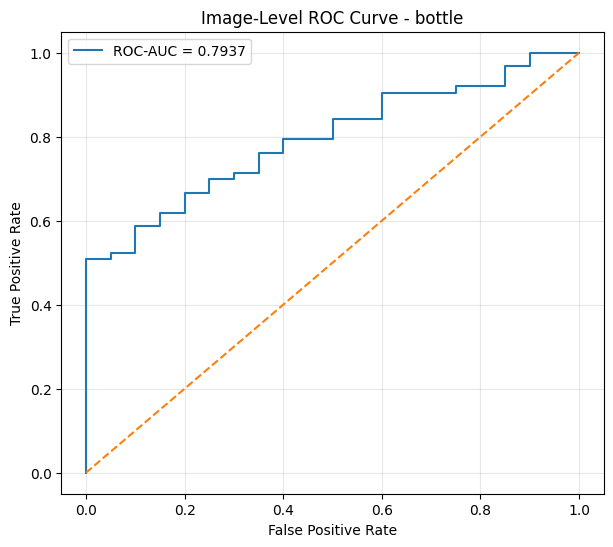

In [30]:
if len(np.unique(test_labels)) == 2:
    fpr, tpr, _ = roc_curve(test_labels, test_scores)
    auc_value = roc_auc_score(test_labels, test_scores)

    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, label=f"ROC-AUC = {auc_value:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Image-Level ROC Curve - {CATEGORY}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

Anomaly score distribution

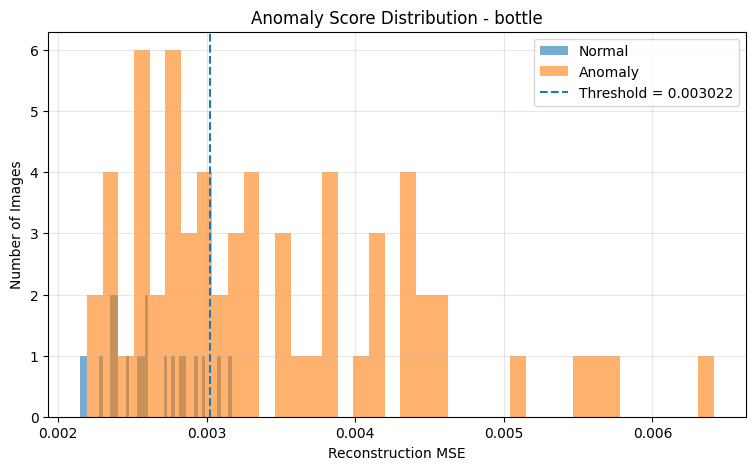

In [31]:
plt.figure(figsize=(9, 5))

normal_scores = test_scores[test_labels == 0]
anomaly_scores = test_scores[test_labels == 1]

plt.hist(normal_scores, bins=40, alpha=0.6, label="Normal")
plt.hist(anomaly_scores, bins=40, alpha=0.6, label="Anomaly")
plt.axvline(
    image_threshold,
    linestyle="--",
    label=f"Threshold = {image_threshold:.6f}"
)

plt.xlabel("Reconstruction MSE")
plt.ylabel("Number of Images")
plt.title(f"Anomaly Score Distribution - {CATEGORY}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Pixel-level defect localization

For each image, the reconstruction error is converted into a heatmap.

For defective test image, MVTec AD provides ground-truth masks. These masks allow the notebook to calculate pixel-level ROC-AUC and thresholded localization metrics.

The localizzation threshold isi derived from normal validation images, keeping the test masks reserved for evaluation.

In [32]:
def find_ground_truth_mask(category_dir, defect_type, image_path):
    if defect_type == "good":
        return None

    image_name = Path(image_path).stem

    # MVTec ground_truth files commonly use:
    # ground_truth/<defect_type>/<image_stem>_mask.png
    candidates = [
        category_dir / "ground_truth" / defect_type / f"{image_name}_mask.png",
        category_dir / "ground_truth" / defect_type / f"{image_name}_mask.jpg",
        category_dir / "ground_truth" / defect_type / f"{image_name}_mask.bmp",
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate

    # Fallback search
    gt_dir = category_dir / "ground_truth" / defect_type
    if gt_dir.exists():
        matches = list(gt_dir.glob(f"{image_name}_mask.*"))
        if matches:
            return matches[0]

    return None


def load_ground_truth_mask(mask_path, image_size):
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return None

    mask = cv2.resize(
        mask,
        (image_size, image_size),
        interpolation=cv2.INTER_NEAREST
    )

    return (mask > 0).astype(np.uint8)


def normalize_heatmap(error_map):
    error_map = np.asarray(error_map, dtype=np.float32)
    min_v = float(error_map.min())
    max_v = float(error_map.max())

    if max_v - min_v < 1e-12:
        return np.zeros_like(error_map)

    return (error_map - min_v) / (max_v - min_v)


Pixel-level evaluation

In [33]:
pixel_true = []
pixel_score = []

localization_rows = []

for path, defect_type, label, error_map in zip(
    test_paths, test_types, test_labels, test_maps
):
    mask_path = find_ground_truth_mask(
        CATEGORY_DIR,
        defect_type,
        path
    )

    if mask_path is None:
        # Normal images have an all-zero mask.
        if label == 0:
            gt_mask = np.zeros((IMAGE_SIZE, IMAGE_SIZE), dtype=np.uint8)
        else:
            # Missing mask: skip this defective sample for pixel metrics.
            continue
    else:
        gt_mask = load_ground_truth_mask(mask_path, IMAGE_SIZE)

    if gt_mask is None:
        continue

    pixel_true.extend(gt_mask.reshape(-1).tolist())
    pixel_score.extend(error_map.reshape(-1).tolist())

    pred_mask = (error_map >= pixel_threshold).astype(np.uint8)

    intersection = np.logical_and(pred_mask == 1, gt_mask == 1).sum()
    union = np.logical_or(pred_mask == 1, gt_mask == 1).sum()

    pred_area = pred_mask.sum()
    gt_area = gt_mask.sum()

    iou = float(intersection / union) if union > 0 else 0.0
    dice = float(
        2 * intersection / (pred_area + gt_area)
    ) if (pred_area + gt_area) > 0 else 0.0

    localization_rows.append({
        "path": path,
        "defect_type": defect_type,
        "iou": iou,
        "dice": dice
    })

pixel_true = np.asarray(pixel_true, dtype=np.uint8)
pixel_score = np.asarray(pixel_score, dtype=np.float32)

pixel_metrics = {
    "pixel_threshold": pixel_threshold,
    "pixel_threshold_method": f"normal_validation_percentile_{PIXEL_THRESHOLD_PERCENTILE}",
    "num_evaluated_pixels": int(len(pixel_true))
}

if len(np.unique(pixel_true)) == 2:
    pixel_metrics["pixel_roc_auc"] = float(
        roc_auc_score(pixel_true, pixel_score)
    )
else:
    pixel_metrics["pixel_roc_auc"] = None

loc_df = pd.DataFrame(localization_rows)

if not loc_df.empty:
    pixel_metrics["mean_iou"] = float(loc_df["iou"].mean())
    pixel_metrics["mean_dice"] = float(loc_df["dice"].mean())
else:
    pixel_metrics["mean_iou"] = None
    pixel_metrics["mean_dice"] = None

print(json.dumps(pixel_metrics, indent=2))


{
  "pixel_threshold": 0.03566422313451767,
  "pixel_threshold_method": "normal_validation_percentile_99.5",
  "num_evaluated_pixels": 1359872,
  "pixel_roc_auc": 0.7668046466118538,
  "mean_iou": 0.065618475227409,
  "mean_dice": 0.11317458928379436
}


# Visualize Predictions and Anomaly Heatmaps

The following visualizations shows:
1. Original image
2. Reconstruction
3. Reconstruction-error heatmap
4. Thresholded defect localization

This visualization can later be adapted directly for the FastAPI application.

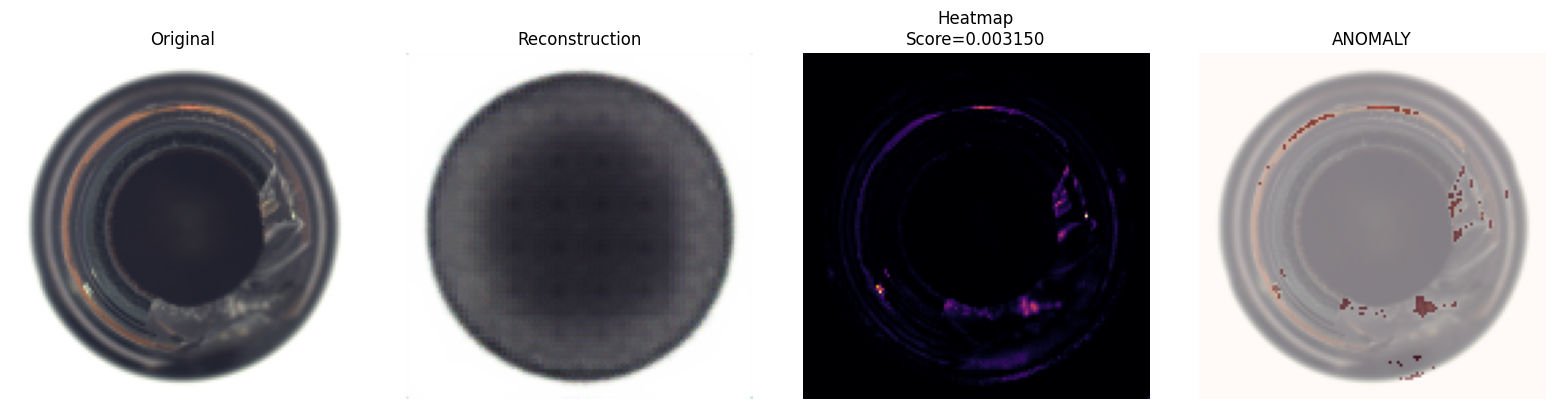

Prediction    : ANOMALY
Anomaly score : 0.00314970
Threshold     : 0.00302153


In [34]:
def load_image_for_display(path):
    image = cv2.imread(str(path), cv2.IMREAD_COLOR)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return cv2.resize(
        image,
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=cv2.INTER_AREA
    )


@torch.no_grad()
def reconstruct_single(path):
    image = load_image_for_display(path)
    x = image.astype(np.float32) / 255.0
    x = np.transpose(x, (2, 0, 1))
    tensor = torch.from_numpy(x).unsqueeze(0).to(device)

    recon = model(tensor).squeeze(0).cpu().numpy()
    recon = np.transpose(recon, (1, 2, 0))
    recon = np.clip(recon, 0, 1)

    original = tensor.squeeze(0).cpu().numpy()
    original = np.transpose(original, (1, 2, 0))

    error_map = ((original - recon) ** 2).mean(axis=2)

    return original, recon, error_map


def show_prediction(path, threshold=image_threshold):
    original, recon, error_map = reconstruct_single(path)

    score = float(error_map.mean())
    prediction = "ANOMALY" if score >= threshold else "NORMAL"

    heatmap = normalize_heatmap(error_map)
    localization = (error_map >= pixel_threshold).astype(np.uint8)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].imshow(original)
    axes[0].set_title("Original")

    axes[1].imshow(recon)
    axes[1].set_title("Reconstruction")

    axes[2].imshow(heatmap, cmap="inferno")
    axes[2].set_title(f"Heatmap\nScore={score:.6f}")

    axes[3].imshow(original)
    axes[3].imshow(
        localization,
        cmap="Reds",
        alpha=0.45
    )
    axes[3].set_title(prediction)

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    print(f"Prediction    : {prediction}")
    print(f"Anomaly score : {score:.8f}")
    print(f"Threshold     : {threshold:.8f}")


# Example: display one anomalous test image if available
anomaly_examples = [
    p for p, y in zip(test_paths, test_labels) if y == 1
]

if anomaly_examples:
    show_prediction(anomaly_examples[0])
else:
    show_prediction(test_paths[0])


# Per-defect-type analysis

MVTec AD contains multiple defect types for each category. This table helps identify whether the reconstruction model behaves differently across defect types.

In [35]:
evaluation_df = pd.DataFrame({
    "path": test_paths,
    "defect_type": test_types,
    "label": test_labels,
    "anomaly_score": test_scores,
    "prediction": pred_labels
})

evaluation_df["prediction_name"] = evaluation_df["prediction"].map({
    0: "NORMAL",
    1: "ANOMALY"
})

per_type = []

for defect_type, group in evaluation_df.groupby("defect_type"):
    if group["label"].nunique() == 2:
        auc = roc_auc_score(group["label"], group["anomaly_score"])
    else:
        auc = None

    per_type.append({
        "defect_type": defect_type,
        "samples": len(group),
        "actual_anomaly_rate": float(group["label"].mean()),
        "predicted_anomaly_rate": float(group["prediction"].mean()),
        "mean_score": float(group["anomaly_score"].mean()),
        "roc_auc": auc
    })

per_type_df = pd.DataFrame(per_type)
display(per_type_df)


,defect_type,samples,actual_anomaly_rate,predicted_anomaly_rate,mean_score,roc_auc
0,broken_large,20,1.0,0.70000,0.003419,None
1,broken_small,22,1.0,0.50000,0.003383,None
2,contamination,21,1.0,0.52381,0.003513,None
3,good,20,0.0,0.10000,0.002612,None


# Export model and inference configuration

The exported checkpoint contains:
- model state dictionary
- catgory
- image size
- image-level threshold
- pixel-level threshold
- threshold methods
- model architecture name

This makes the checkpoint easier to load from the future FastAPI service.

The actual model file should be uploaded to Hugging Face rather than commited to GitHub repository.

In [36]:
model_path = Path(OUTPUT_DIR) / f"mvtec_{CATEGORY}_autoencoder.pt"

checkpoint = {
    "model_name": "LightweightConvAutoencoder",
    "category": CATEGORY,
    "image_size": IMAGE_SIZE,
    "state_dict": model.state_dict(),
    "image_threshold": image_threshold,
    "image_threshold_percentile": THRESHOLD_PERCENTILE,
    "pixel_threshold": pixel_threshold,
    "pixel_threshold_percentile": PIXEL_THRESHOLD_PERCENTILE,
    "input_range": [0.0, 1.0],
    "score": "mean_squared_reconstruction_error",
    "framework": "pytorch",
}

torch.save(checkpoint, model_path)

print("Saved:", model_path)
print(f"Size: {model_path.stat().st_size / (1024**2):.2f} MB")


Saved: /content/mvtec_outputs/mvtec_bottle_autoencoder.pt
Size: 2.56 MB


Save evaluation result

In [37]:
results_dir = Path(OUTPUT_DIR) / "results"
metrics_dir = results_dir / "metrics"
visualizations_dir = results_dir / "visualizations"

metrics_dir.mkdir(parents=True, exist_ok=True)
visualizations_dir.mkdir(parents=True, exist_ok=True)

with open(metrics_dir / "evaluation_results.json", "w") as f:
    json.dump(
        {
            "category": CATEGORY,
            "image_level": image_metrics,
            "pixel_level": pixel_metrics
        },
        f,
        indent=2
    )

per_type_df.to_csv(
    metrics_dir / "per_defect_type_results.csv",
    index=False
)

pd.DataFrame(history).to_csv(
    metrics_dir / "training_history.csv",
    index=False
)

# Save a copy of the checkpoint in the results directory.
shutil.copy2(
    model_path,
    results_dir / model_path.name
)

print("Results saved under:", results_dir)


Results saved under: /content/mvtec_outputs/results


# Generate a Compact Inference Configuration

The FastAPI application can use the same values stored in the checkpoint. A separate JSON file is also generated for easier inspection.

In [38]:
inference_config = {
    "model_name": "LightweightConvAutoencoder",
    "category": CATEGORY,
    "image_size": IMAGE_SIZE,
    "image_threshold": image_threshold,
    "pixel_threshold": pixel_threshold,
    "threshold_method": f"normal_validation_percentile_{THRESHOLD_PERCENTILE}",
    "pixel_threshold_method": f"normal_validation_percentile_{PIXEL_THRESHOLD_PERCENTILE}",
    "input_normalization": "pixel / 255.0",
    "anomaly_score": "mean squared reconstruction error",
    "framework": "PyTorch"
}

config_path = Path(OUTPUT_DIR) / "inference_config.json"

with open(config_path, "w") as f:
    json.dump(inference_config, f, indent=2)

print(config_path.read_text())


{
  "model_name": "LightweightConvAutoencoder",
  "category": "bottle",
  "image_size": 128,
  "image_threshold": 0.003021534765139222,
  "pixel_threshold": 0.03566422313451767,
  "threshold_method": "normal_validation_percentile_99.0",
  "pixel_threshold_method": "normal_validation_percentile_99.5",
  "input_normalization": "pixel / 255.0",
  "anomaly_score": "mean squared reconstruction error",
  "framework": "PyTorch"
}


# Example Standalone Inference Function

This function mirrors what the future FastAPI backend needs to do:

```text
Uploaded image
      ↓
Resize + normalize
      ↓
Autoencoder
      ↓
Reconstruction error
      ↓
Anomaly score
      ↓
Threshold
      ↓
NORMAL / ANOMALY
      ↓
Anomaly heatmap
```

In [39]:
@torch.no_grad()
def predict_image(image_path, model, image_threshold, pixel_threshold):
    model.eval()

    image_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise ValueError(f"Cannot read image: {image_path}")

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(
        image_rgb,
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=cv2.INTER_AREA
    )

    x = resized.astype(np.float32) / 255.0
    x_tensor = torch.from_numpy(
        np.transpose(x, (2, 0, 1))
    ).unsqueeze(0).to(device)

    reconstruction = model(x_tensor)

    error = (
        (x_tensor - reconstruction) ** 2
    ).mean(dim=1).squeeze(0).cpu().numpy()

    anomaly_score = float(error.mean())
    prediction = (
        "ANOMALY"
        if anomaly_score >= image_threshold
        else "NORMAL"
    )

    heatmap = normalize_heatmap(error)
    localization_mask = (
        error >= pixel_threshold
    ).astype(np.uint8)

    return {
        "prediction": prediction,
        "anomaly_score": anomaly_score,
        "image_threshold": float(image_threshold),
        "pixel_threshold": float(pixel_threshold),
        "heatmap": heatmap,
        "localization_mask": localization_mask
    }


# Example:
result = predict_image(
    test_paths[0],
    model,
    image_threshold,
    pixel_threshold
)

print("Prediction:", result["prediction"])
print("Anomaly score:", result["anomaly_score"])


Prediction: ANOMALY
Anomaly score: 0.0031497012823820114


# Final Experiment Summmary

The following cell produces a compact summary that can be copied into the project documentation or used when preparing the Hugging Face model card.

In [40]:
summary = {
    "dataset": "MVTec Anomaly Detection",
    "dataset_source": "Kaggle: ipythonx/mvtec-ad",
    "category": CATEGORY,
    "framework": "PyTorch",
    "model": "Lightweight Convolutional Autoencoder",
    "input_size": f"{IMAGE_SIZE}x{IMAGE_SIZE}x3",
    "training_samples": len(train_paths),
    "validation_samples": len(val_paths),
    "test_samples": len(test_df),
    "train_epochs_completed": len(history["train_loss"]),
    "best_validation_mse": best_val_loss,
    "image_threshold": image_threshold,
    "image_threshold_method": f"{THRESHOLD_PERCENTILE}th percentile of normal validation scores",
    "pixel_threshold": pixel_threshold,
    "pixel_threshold_method": f"{PIXEL_THRESHOLD_PERCENTILE}th percentile of normal validation pixels",
    "image_roc_auc": image_metrics["roc_auc"],
    "image_average_precision": image_metrics["average_precision"],
    "image_accuracy": image_metrics["accuracy"],
    "image_precision": image_metrics["precision"],
    "image_recall": image_metrics["recall"],
    "image_f1": image_metrics["f1"],
    "pixel_roc_auc": pixel_metrics["pixel_roc_auc"],
    "mean_iou": pixel_metrics["mean_iou"],
    "mean_dice": pixel_metrics["mean_dice"],
    "model_file": str(model_path)
}

print(json.dumps(summary, indent=2))

with open(Path(OUTPUT_DIR) / "experiment_summary.json", "w") as f:
    json.dump(summary, f, indent=2)


{
  "dataset": "MVTec Anomaly Detection",
  "dataset_source": "Kaggle: ipythonx/mvtec-ad",
  "category": "bottle",
  "framework": "PyTorch",
  "model": "Lightweight Convolutional Autoencoder",
  "input_size": "128x128x3",
  "training_samples": 168,
  "validation_samples": 41,
  "test_samples": 83,
  "train_epochs_completed": 30,
  "best_validation_mse": 0.0023148856352923847,
  "image_threshold": 0.003021534765139222,
  "image_threshold_method": "99.0th percentile of normal validation scores",
  "pixel_threshold": 0.03566422313451767,
  "pixel_threshold_method": "99.5th percentile of normal validation pixels",
  "image_roc_auc": 0.7936507936507937,
  "image_average_precision": 0.9340352680392678,
  "image_accuracy": 0.6506024096385542,
  "image_precision": 0.9473684210526315,
  "image_recall": 0.5714285714285714,
  "image_f1": 0.7128712871287128,
  "pixel_roc_auc": 0.7668046466118538,
  "mean_iou": 0.065618475227409,
  "mean_dice": 0.11317458928379436,
  "model_file": "/content/mvtec_o

# Conclusion

This notebook implements a complete lightweight MVTec AD anomaly-detection pipeline:
1. Download the dataset from Kaggle.
2. Select one MVTec AD category.
3. Train a compact convolutional autoencoder using only normal training images.
4. Select an image-level threshold from normal validation reconstruction errors.
5. Evaluate image-level anomaly detection on the official test split.
6. Generate reconstruction-error heatmaps.
7. Evaluate defect localization against MVTec ground-truth masks.
8. Export the trained model and inference configuration.
9. Prepare the model for external hosting on Hugging Face.


### Importannt deployment note
Because MVTec AD contains differenct product categories, the exported model is **category-specific**. The FastAPI application should use the same category, image size, preprocessing, model architecture, and threshold stored in the exported checkpoint.

For example:
```text
_autoencoder.pt
     |
     +-- category = bottle
     +-- image_threshold = ...
     +-- pixel_threshold = ...
     |
     v
FastAPI
     |
     v
Image Upload
     |
     v
Inference
     |
     +-- NORMAL / ANOMALY
     +-- anomaly score
     +-- heatmap
     +-- localization
```

This design keeps the training notebook, model artifact, and web application clearly separated while maintaining a reproducible end-to-end workflow.